In [ ]:
import sys, os
root = os.path.abspath(os.path.join('..'))
if root not in sys.path:
    sys.path.append(root)

import numpy as np
from src.data_loader import load_mnist_multiclass
from src.softmax_regression import SoftmaxRegression, cross_validate, learning_curve, regularization_sweep,plot_learning_curve, plot_regularization_sweep,diagnose_bias_variance
from src.utils import plot_confusion_matrix, print_metrics, plot_loss_curves, accuracy

print("Imports OK")

Imports OK


In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = load_mnist_multiclass()
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (56000, 2025), Val: (7000, 2025), Test: (7000, 2025)


## 1. Cross-Validation: Pick Best alpha

In [3]:
for alpha in [0.1, 0.5, 1.0, 1.3]:
    mean_acc, _ = cross_validate(X_train, y_train, k=3, alpha=alpha, lambda_=0.01, num_iter=500)
    print(f"alpha={alpha:.1f}  CV accuracy: {mean_acc:.4f}")

alpha=0.1  CV accuracy: 0.9483
alpha=0.5  CV accuracy: 0.9617
alpha=1.0  CV accuracy: 0.9676
alpha=1.3  CV accuracy: 0.9692


## 2. Cross-Validation: Pick best lambda_

In [7]:
for lam in [0, 1e-4, 1e-3, 1e-2, 0.1,0.5]:
    mean_acc, _ = cross_validate(X_train, y_train, k=3, alpha=1.3, lambda_=lam, num_iter=500)
    print(f"lambda={lam:.4f}  CV accuracy: {mean_acc:.4f}")

lambda=0.0000  CV accuracy: 0.9692
lambda=0.0001  CV accuracy: 0.9692
lambda=0.0010  CV accuracy: 0.9692
lambda=0.0100  CV accuracy: 0.9692
lambda=0.1000  CV accuracy: 0.9692
lambda=0.5000  CV accuracy: 0.9691


## 3. Final Training

In [8]:
model = SoftmaxRegression(alpha=1.3, num_iter=2000, lambda_=0.1, reg_type='l2')
model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
print(f"Trained for {model.actual_iter} iterations")

Trained for 2000 iterations


## 4. Loss Curves

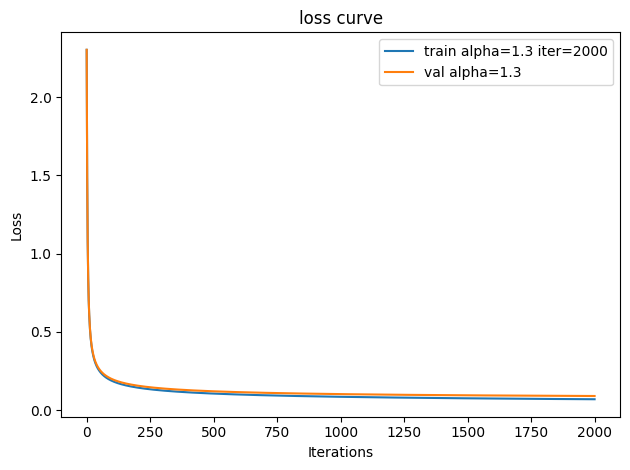

In [9]:
plot_loss_curves(model)

## 5. Learning Curve

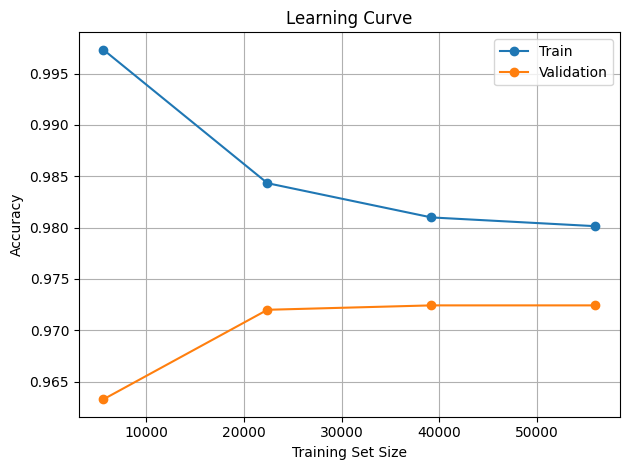

In [11]:
sizes, train_scores, val_scores = learning_curve(
    SoftmaxRegression, X_train, y_train, X_val, y_val,
    train_sizes=np.linspace(0.1, 1.0, 4),
    model_kwargs={'alpha': 1.3, 'num_iter': 2000, 'lambda_': 0.01}
)
plot_learning_curve(sizes, train_scores, val_scores)

## 6. Confusion Matrix

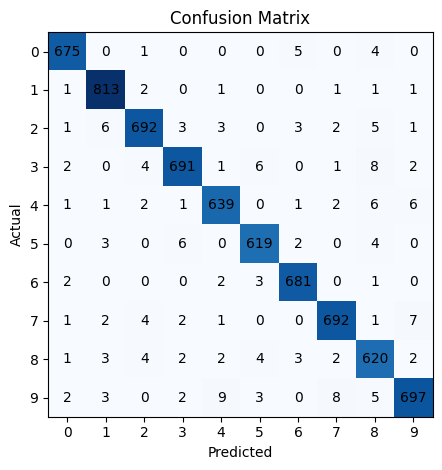

In [12]:
y_pred = model.predict(X_test)
plot_confusion_matrix(y_test, y_pred, num_classes=10)

## 7. Bias-Variance Diagnosis

In [13]:
train_acc = accuracy(y_train, model.predict(X_train))
val_acc = accuracy(y_val, model.predict(X_val))
test_acc = accuracy(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")
diagnose_bias_variance(train_acc, val_acc,model.losses[-1], model.val_losses[-1])

Test Accuracy: 0.9741
=== Bias-Variance Diagnosis ===
Train Accuracy: 0.9801
Val Accuracy:   0.9724
Gap:            0.0077
Train Loss:     0.0703
Val Loss:       0.0911
Result: GOOD FIT


Train Accuracy: 0.9801
Train Precision (macro): 0.9801
Train Recall (macro): 0.9801
Train F1 Score (macro): 0.9801
Val Accuracy: 0.9724
Val Precision (macro): 0.9723
Val Recall (macro): 0.9724
Val F1 Score (macro): 0.9723
Test Accuracy: 0.9741
Test Precision (macro): 0.9739
Test Recall (macro): 0.9739
Test F1 Score (macro): 0.9739


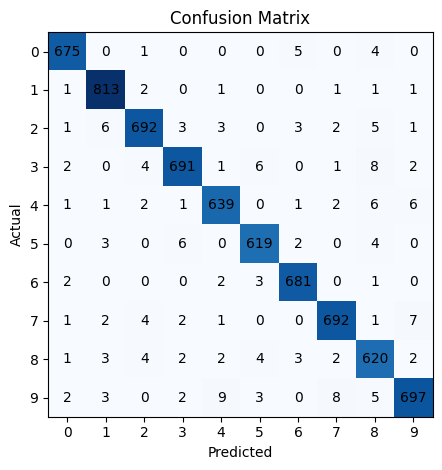

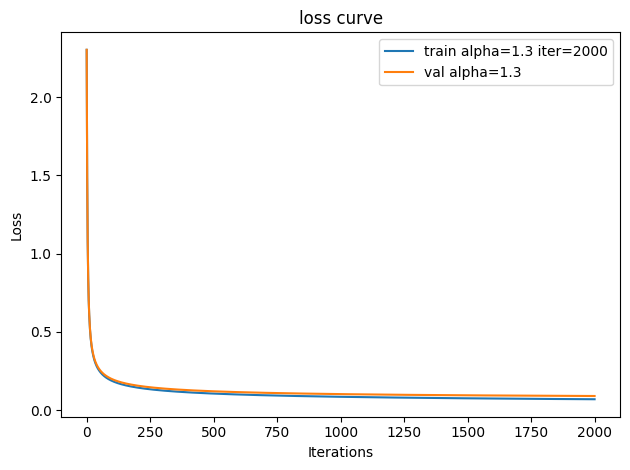

In [15]:

y_pred_train = model.predict(X_train)
y_pred_val   = model.predict(X_val)
y_pred_test  = model.predict(X_test)

print_metrics(y_train, y_pred_train, y_val, y_pred_val, y_test, y_pred_test, model)

Train Accuracy: 0.9801
Train Precision (macro): 0.9801
Train Recall (macro): 0.9801
Train F1 Score (macro): 0.9801
Val Accuracy: 0.9724
Val Precision (macro): 0.9723
Val Recall (macro): 0.9724
Val F1 Score (macro): 0.9723
Test Accuracy: 0.9741
Test Precision (macro): 0.9739
Test Recall (macro): 0.9739
Test F1 Score (macro): 0.9739


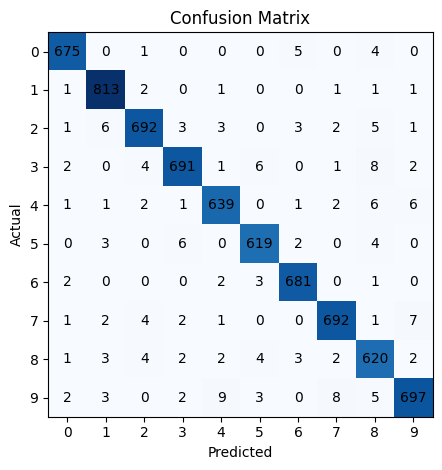

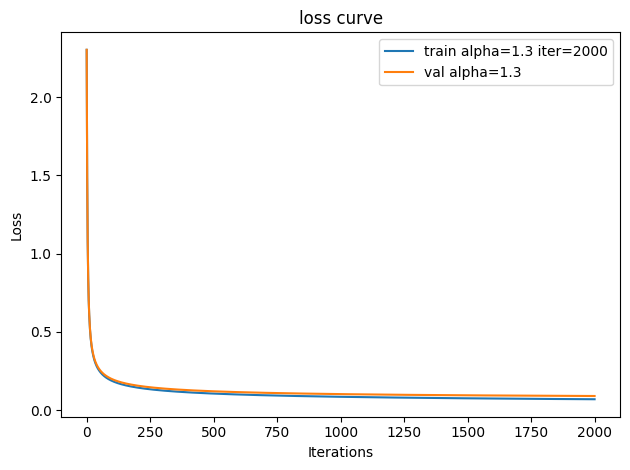

In [17]:
# Predict on all splits
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)
print_metrics(y_train, y_pred_train, y_val, y_pred_val, y_test, y_pred_test, model)